In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
from matplotlib.lines import Line2D

In [2]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)

idmrg_file = '../../data/iDMRG/scanChi800/corrs/results.h5'
df_i = read_corrs(idmrg_file)

/tmp/ipykernel_194529/2383182260.py:15: RuntimeWarning: divide by zero encountered in power
  ax.plot(xarr, prefixes[j] * (xarr)**(-4/Ks), ls=':')


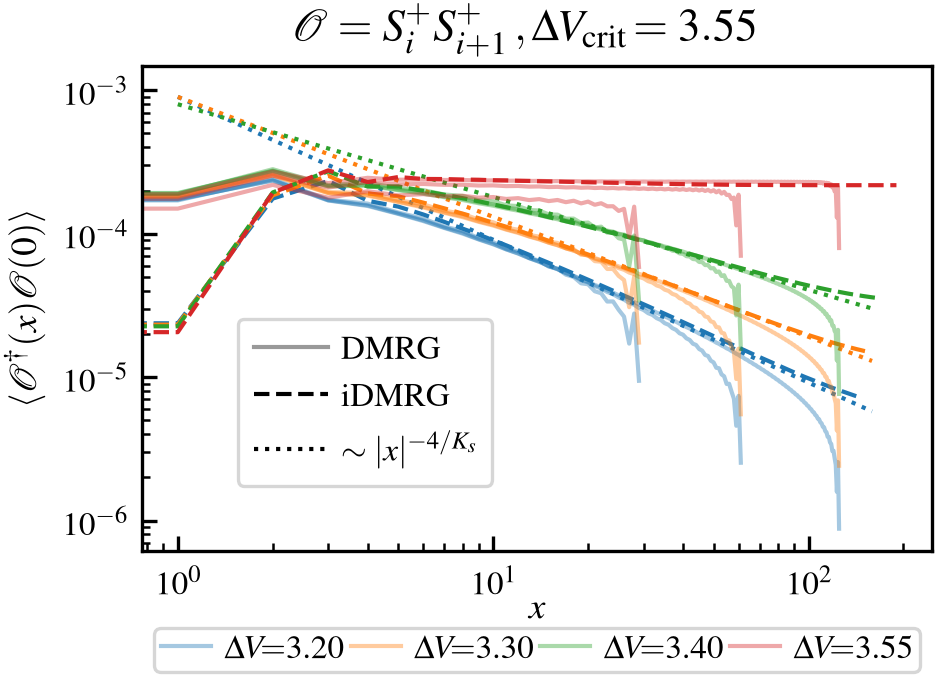

In [30]:
fig, ax = plt.subplots(1)
dVvals = [3.2, 3.3, 3.4, 3.55, ]
prefixes = np.array([0.0009,0.0009, 0.0008, 1])
for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    ax.plot(np.abs(seldf_i["spin2_corr"].values[0]), c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    for nval in (64, 128, 256,):
        label = r'$\Delta V\!\!\!\!= $' + f'{dVval:.2f}' if nval==256 else None
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        ax.plot(np.abs(seldf["spin2vec"].values[0]), c=col, alpha=0.4, label=label)
        if dVval < 3.55 and nval == 256: 
            xarr = np.arange(160)
            Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)
            ax.plot(xarr, prefixes[j] * (xarr)**(-4/Ks), ls=':')
        
ax.set_ylabel(r'$\langle \mathcal{O}^\dagger(x)\mathcal{O}(0)\rangle$')
ax.set_xlabel(r'$x$', labelpad=-2)
ax.set_xscale('log')
ax.set_yscale('log')

fig.suptitle(r"$ \mathcal{O} = S^+_iS^+_{i+1}\, , \Delta V_{\mathrm{crit}}\!= 3.55$")

handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels, ncol=len(dVvals), columnspacing=0.2, labelspacing=0.2,
                 loc="lower center", bbox_to_anchor=(0.5, -0.25), 
                 frameon=True, fancybox=True, borderaxespad=0, 
                 bbox_transform=ax.transAxes)

# --- Internal legend ---
internal_handles = [
    Line2D([0], [0], color='black', lw=1.0, ls='-', alpha=0.4),
    Line2D([0], [0], color='black', lw=1.0, ls='--'),
    Line2D([0], [0], color='black', lw=1.0, ls=':')
]

internal_labels = [r'DMRG', 'iDMRG', r'$\sim |x|^{-4/K_s}$']

ax.legend(
    internal_handles, internal_labels,
    loc='lower left',  bbox_to_anchor=(0.10, 0.10),
    frameon=True, fancybox=True, borderpad=0.5, handlelength=2.2
)

fig.savefig("figures/Show_LRO.pdf", bbox_inches='tight')

/tmp/ipykernel_194529/3870940992.py:28: RuntimeWarning: divide by zero encountered in power
  ax.plot(xarr, prefixes[j] * (xarr)**(powerlaw), ls=':')


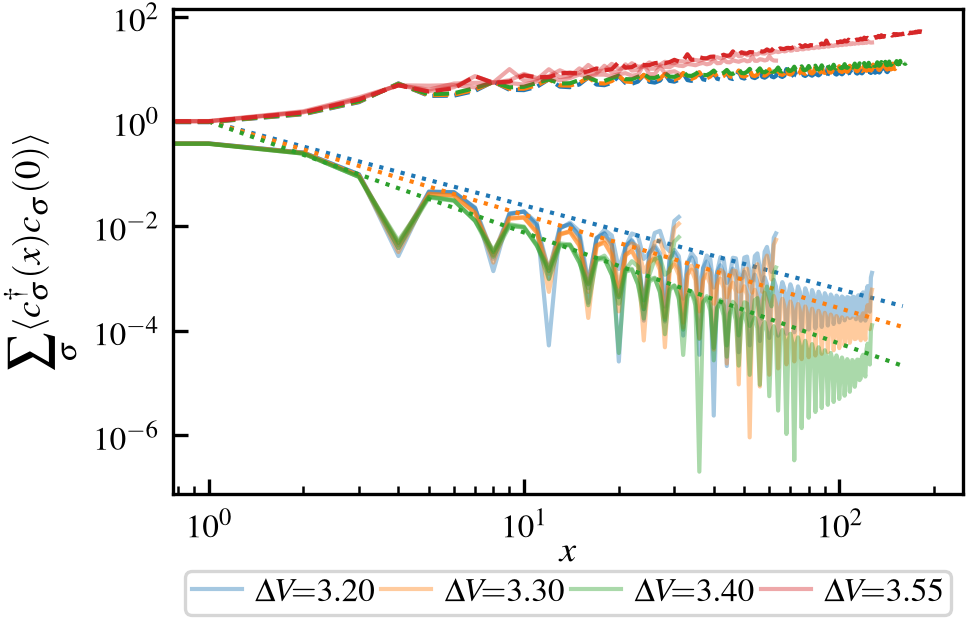

In [44]:
fig, ax = plt.subplots(1)
dVvals = [3.2, 3.3, 3.4, 3.55, ]
prefixes = np.array([1,1,1, 1])
for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    yqty_i = np.abs(seldf_i["electron_corr"].values[0])
    yqty_i = -np.log(yqty_i)
    # if np.isclose(dVval, 3.55):
    #     yqty_i = -np.log(yqty_i)
    #     xvals = np.arange(len(yqty_i))
    #     fs = slice(20, -10)
    #     m, logc = np.polyfit(np.log(xvals[fs]), np.log(yqty_i[fs]), 1)
    #     print(f'm = {m}')
    #     ax.plot(np.exp(logc) * xvals**m, c=col, ls=':')
    ax.plot(yqty_i, c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    for nval in (64, 128, 256,):
        label = r'$\Delta V\!\!\!\!= $' + f'{dVval:.2f}' if nval==256 else None
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        yqty = np.abs(seldf["electron_conn"].values[0])
        if np.isclose(dVval, 3.55):
            yqty = -np.log(yqty)
        ax.plot(yqty, c=col, alpha=0.4, label=label)
        if dVval < 3.55 and nval == 256: 
            xarr = np.arange(160)
            Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)
            powerlaw = -0.25 * (Kc + 1./Kc + Ks + 1./Ks)
            ax.plot(xarr, prefixes[j] * (xarr)**(powerlaw), ls=':')
        
ax.set_ylabel(r'$\displaystyle\sum_{\sigma}\langle c^\dagger_\sigma(x)c^{\phantom\dagger}_\sigma(0)\rangle$')
ax.set_xlabel(r'$x$', labelpad=-2)
ax.set_xscale('log')
ax.set_yscale('log')

# fig.suptitle(r"$ \mathcal{O} = S^+_iS^+_{i+1}\, , \Delta V_{\mathrm{crit}}\!= 3.55$")

handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels, ncol=len(dVvals), columnspacing=0.2, labelspacing=0.2,
                 loc="lower center", bbox_to_anchor=(0.5, -0.25), 
                 frameon=True, fancybox=True, borderaxespad=0, 
                 bbox_transform=ax.transAxes)

# --- Internal legend ---
# internal_handles = [
#     Line2D([0], [0], color='black', lw=1.0, ls='-', alpha=0.4),
#     Line2D([0], [0], color='black', lw=1.0, ls='--'),
#     Line2D([0], [0], color='black', lw=1.0, ls=':')
# ]

# internal_labels = [r'DMRG', 'iDMRG', r'$\sim |x|^{-4/K_s}$']

# ax.legend(
#     internal_handles, internal_labels,
#     loc='lower left',  bbox_to_anchor=(0.10, 0.10),
#     frameon=True, fancybox=True, borderpad=0.5, handlelength=2.2
# )

# fig.savefig("figures/Show_LRO.pdf", bbox_inches='tight')